# SSY098
## Lab 2: Image Registration

In this lab you will learn how to use detected keypoint features from SIFT to register a source image to a target image. In order to do this, we must also learn how to warp images from the source coordinate system to the target coordinate system.

Specifically, you will use knowledge from the lectures on
- Image features
- Model fitting
- Geometric models
- Image registration

**Observe**: You should not install any other packages than the ones given in the pre-amble. You are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV and (to an extent) SimpleITK. You are allowed to use any methods in the packages that you see fit to solve the problems. It is highly encouraged to look at the documentation and search for usage instructions online, before asking for help.

**Observe**: Write your answers to questions directly in the cells denoted with **Your answer**.

## Submission Requirements:
Your final lab submission should include:
1. Your executed **notebook file** (`.ipynb`) including an AI usage statement.
2. A **HTML printout** of the executed notebook with all outputs visible. 

### AI Usage Statement
In this lab, I used AI tools (Gemini) as a learning assistant. Specifically, I used AI to:

1. Help me better understand the lab instructions and theoretical concepts.
2. Get suggestions on which OpenCV/Python functions to use for the implementation.
3. Optimise my written text answers for better clarity.
4. Help to debug the mistakes.
5. In task1.2, help me to get this equatuion:A = R @ K @ np.linalg.inv(R)

### Introduction
The purpose of this lab is to learn how to register two images using affine transformations. An affine transformation is written as:


$$
\left(\begin{array}{l}
x' \\
y'
\end{array}\right)=\left(\begin{array}{ll}
a & b \\
c & d
\end{array}\right)\left(\begin{array}{l}
x \\
y
\end{array}\right)+\left(\begin{array}{l}
t_{x} \\
t_{y}
\end{array}\right)=A\left(\begin{array}{l}
x \\
y
\end{array}\right)+t.
$$

It can also be written using homogeneous coordinates as:

$$
\left(\begin{array}{l}
x' \\
y' \\
1
\end{array}\right)=\left(\begin{array}{ll}
a & b & t_{x}\\
c & d & t_{y}\\
0 & 0 & 1
\end{array}\right)\left(\begin{array}{l}
x \\
y \\
1
\end{array}\right)=T\left(\begin{array}{l}
x \\
y \\
1
\end{array}\right).
$$
where $T$ is an affine transformation matrix. Apart from rotation, translation and scaling, it also allows strecthing the image in an arbitrary dimension.

### Utility scripts
Below are some utility scripts for this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from typing import Tuple, List, Sequence, Union, Optional
import pandas as pd
import SimpleITK as sitk

def compare_estimated_transform(
        A_true: np.ndarray,
        t_true: np.ndarray,
        A_est: np.ndarray,
        t_est: np.ndarray,
) -> None:
    """
    Compares the true and estimated affine transformation parameters.
    
    Args:
    - A_true (np.ndarray): The true affine transformation matrix.
    - t_true (np.ndarray): The true translation vector.
    - A_est (np.ndarray): The estimated affine transformation matrix.
    - t_est (np.ndarray): The estimated translation vector.

    Returns:
    None
    
    """
    df_for_printing = pd.DataFrame(columns=["a", "b", "c", "d", "tx", "ty"],
                                    data=[[A_true[0, 0], A_true[0, 1], A_true[1, 0], A_true[1, 1], t_true[0, 0], t_true[1, 0]],
                                          [A_est[0, 0], A_est[0, 1], A_est[1, 0], A_est[1, 1], t_est[0, 0], t_est[1, 0]]],
                                    index=["True", "Estimated"])
    display(df_for_printing)

def plot_affine_test_case(
        pts: np.ndarray,
        pts_prime: np.ndarray,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plots the affine test case without outliers.
    
    Args:
    - pts (np.ndarray): The source points.
    - pts_prime (np.ndarray): The target points.

    Returns:
    - tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    
    """
    f, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Plot the original points
    ax.scatter(pts[0,:], pts[1,:], label='Original points', color='g', marker='o', facecolor='none')

    # Plot the transformed points
    ax.scatter(pts_prime[0,:], pts_prime[1,:], label='Transformed points', color='g')

    # Plot line between original and transformed points
    for i in range(pts.shape[1]):
        ax.quiver(pts[0,i], pts[1,i], 
                pts_prime[0,i] - pts[0,i], 
                pts_prime[1,i] - pts[1,i], 
                angles='xy', 
                scale_units='xy', 
                scale=1, 
                color='g', 
                alpha=0.2, 
                )

    # Set the limits of the plot to match the transformed points
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Points in an 'image'")

    # Add a legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes)
    
    return f, ax


def plot_affine_test_case_outlier(
        pts: np.ndarray,
        pts_prime: np.ndarray,
        outlier_idxs: np.ndarray,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plots the affine test case with outliers.
    
    Args:
    - pts (np.ndarray): The source points.
    - pts_prime (np.ndarray): The target points.
    - outlier_idxs (np.ndarray): The indices of the outliers.

    Returns:
    - tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    
    """
    f, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Plot the original points
    inlier_pts = pts[:, ~outlier_idxs]
    ax.scatter(inlier_pts[0,:], inlier_pts[1,:], label='Original inliers', color='g', marker='o', facecolor='none')

    outlier_pts = pts[:, outlier_idxs]
    ax.scatter(outlier_pts[0,:], outlier_pts[1,:], label='Original outliers', color='r', marker='o', facecolor='none')

    # Plot the transformed points
    inlier_pts_prime = pts_prime[:, ~outlier_idxs]
    outlier_pts_prime = pts_prime[:, outlier_idxs]
    ax.scatter(inlier_pts_prime[0,:], inlier_pts_prime[1,:], label='Transformed inliers', color='g')
    ax.scatter(outlier_pts_prime[0,:], outlier_pts_prime[1,:], label='Transformed outliers', color='r')

    # Plot line between inlier and transformed points
    for i in range(pts.shape[1]):

        # Check if the point is an outlier
        outlier = outlier_idxs[i]
        if outlier:

            ax.quiver(pts[0,i], pts[1,i], 
                    pts_prime[0,i] - pts[0,i], 
                    pts_prime[1,i] - pts[1,i], 
                    angles='xy', 
                    scale_units='xy', 
                    scale=1, 
                    color='r', 
                    alpha=0.2, 
                    )
        else:

            ax.quiver(pts[0,i], pts[1,i], 
                    pts_prime[0,i] - pts[0,i], 
                    pts_prime[1,i] - pts[1,i], 
                    angles='xy', 
                    scale_units='xy', 
                    scale=1, 
                    color='g', 
                    alpha=0.2, 
                    )

    # Set the limits of the plot to match the transformed points
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Points in an 'image'")

    # Add a legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes)
    
    return f, ax

def plot_affine_test_case_outlier_with_est(
        pts: np.ndarray,
        pts_prime: np.ndarray,
        pts_est: np.ndarray,
        outlier_idxs: np.ndarray,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plots the affine test case with outliers and estimated points.
    
    Args:
    - pts (np.ndarray): The source points.
    - pts_prime (np.ndarray): The target points.
    - pts_est (np.ndarray): The estimated points.
    - image_width (int): The width of the image.
    - image_height (int): The height of the image.
    - outlier_idxs (np.ndarray): The indices of the outliers.

    Returns:
    tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    
    """
    f, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Plot the original points
    inlier_pts = np.delete(pts, outlier_idxs, axis=1)
    ax.scatter(inlier_pts[0,:], inlier_pts[1,:], label='Original inliers', color='g', marker='o', facecolor='none')

    outlier_pts = pts[:, outlier_idxs]
    ax.scatter(outlier_pts[0,:], outlier_pts[1,:], label='Original outliers', color='r', marker='o', facecolor='none')

    # Plot the transformed points
    inlier_pts_prime = np.delete(pts_prime, outlier_idxs, axis=1)
    outlier_pts_prime = pts_prime[:, outlier_idxs]
    ax.scatter(inlier_pts_prime[0,:], inlier_pts_prime[1,:], label='Transformed inliers', color='g')
    ax.scatter(outlier_pts_prime[0,:], outlier_pts_prime[1,:], label='Transformed outliers', color='r')

    # Plot the estimated inlier points
    inlier_pts_est = np.delete(pts_est, outlier_idxs, axis=1)
    ax.scatter(inlier_pts_est[0,:], inlier_pts_est[1,:], label='Estimated transform on inliers', color='lightgreen', marker='x')

    # Plot the estimated inlier points
    outlier_pts_est = pts_est[:, outlier_idxs]
    ax.scatter(outlier_pts_est[0,:], outlier_pts_est[1,:], label='Estimated transform on outliers', color='orange', marker='x')


    # Plot line between inlier and transformed points
    for i in range(pts.shape[1]):

        # Check if the point is an outlier
        outlier = outlier_idxs[i]
        if outlier:

            ax.quiver(pts[0,i], pts[1,i], 
                    pts_prime[0,i] - pts[0,i], 
                    pts_prime[1,i] - pts[1,i], 
                    angles='xy', 
                    scale_units='xy', 
                    scale=1, 
                    color='r', 
                    alpha=0.2, 
                    )
        else:

            ax.quiver(pts[0,i], pts[1,i], 
                    pts_prime[0,i] - pts[0,i], 
                    pts_prime[1,i] - pts[1,i], 
                    angles='xy', 
                    scale_units='xy', 
                    scale=1, 
                    color='g', 
                    alpha=0.2, 
                    )

    # Set the limits of the plot to match the transformed points
    ax.set_aspect('equal', adjustable='box')
    ax.set_title("Points in an 'image'")

    # Add a legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes)
    
    return f, ax

### Task 1.1 Transforms and registration
In general, an estimation problem where the minimal of amount of measurements is used to estimate the unknown parameters is called a minimal problem. What is the minimal number of point correspondences, $K$, required in order to estimate an affine transformation between two images?

**Your Answer**:

The minimal number of point correspondences, $K$, is 3.

An affine transformation is defined by 6 unknown parameters. Since each point correspondence provides 2 independent linear equations (x, y), we need at least 3 points to solve for all 6 parameters. 

### Task 1.2
_Warping_ is the process of transforming an image using a coordinate transformation. Typically, this is done using inverse warping, where we for each pixel in the target image we determine where it originates from in the source image and sample its intensity value there. The function `cv2.warpPerspective` from OpenCV may be used to transform a source image using an affine matrix. Note that the function expects a transformation matrix mapping source to target coordinates (i.e. forward mapping). Internally, however, it inverts this transformation and performs inverse warping to compute the output image.

Load the image `mona.png` to the variable `img`. Play around with the values in $A, t$ to see the results and understand the effect of how to rotate, translate and stretch.

In [2]:
def read_image(image_path: str) -> np.ndarray:
    """
    Read an image from the specified path.
    
    Args:
    - image_path (str): The path to the image file.
    
    Returns:
    - np.ndarray: The image as a NumPy array.
    """
    return cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)


def affine_warp(source: np.ndarray, affine_matrix: np.ndarray, target_shape: np.ndarray) -> np.ndarray:
    """
    Warp the source image to the target image using an affine transformation.
    
    Args:
    - source (np.ndarray): The source image to be warped.
    - affine_matrix (np.ndarray): The affine transformation matrix.
    - target_shape (np.ndarray): The shape of the target image.
    
    Returns:
    - np.ndarray: The warped image.
    """
    dsize = (target_shape[1], target_shape[0])
    M = affine_matrix.astype(np.float32)
    return cv2.warpPerspective(source, M, dsize)

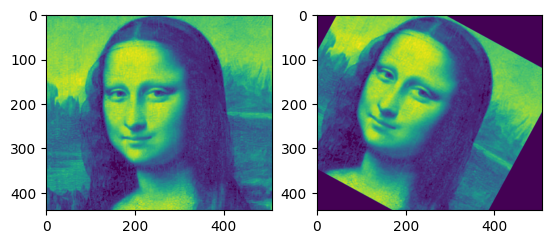

In [3]:
img = read_image('./data/mona.png'); 

# Square transformation matrix
T = np.array([[0.88, -0.48, 100],
              [0.48, 0.88, -100],
              [0, 0, 1]])

warped = affine_warp(img, T, img.shape)

f, ax = plt.subplots(1, 2)
ax[0].imshow(img)
ax[1].imshow(warped)
plt.show()

Change the values in $A$ and $t$ in the transformation matrix $T$ to see what happens. Swap $A$ for the identity matrix to try a pure translation. 

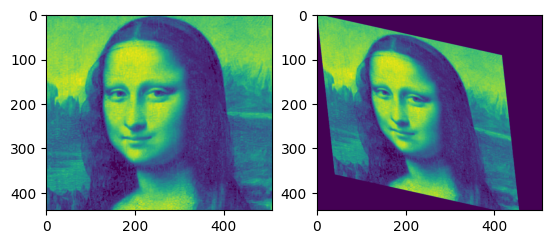

In [4]:
# YOUR CODE HERE
T = np.array([[0.9, 0.1, 0],
              [0.2, 0.9, 0],
              [0, 0, 1.1]])

warped = affine_warp(img, T, img.shape); 

f, ax = plt.subplots(1, 2)
ax[0].imshow(img)
ax[1].imshow(warped)
plt.show()

Lastly, if one would like to stretch the image along the x-axis, one simply applies $A$ as a diagonal matrix with some stretching factor $k$. Create a stretching matrix with a factor $k$ along a diagonal direction with an affine transformation and apply to `mona`.

Remember that `affine_warp` function takes a square transformation matrix $T$ as input.

In [5]:
k = 2
t = np.array([[0.0, 0.0]])

# YOUR CODE HERE
theta = np.atan2(img.shape[1], img.shape[0])
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

K = np.array([[k, 0],
              [0, 1.0]])

A = R @ K @ np.linalg.inv(R)

# Create square transformation matrix
T = np.zeros((3, 3))
T[:2, :2] = A
T[:2, 2] = t
T[2, 2] = 1.0

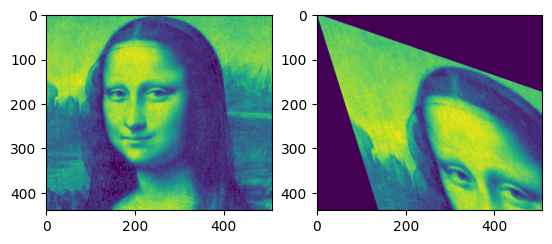

In [6]:
warped = affine_warp(img, T, img.shape)

f, ax = plt.subplots(1, 2)
ax[0].imshow(img)
ax[1].imshow(warped)
plt.show()

### Task 1.3
For any estimation task it is a good idea to have at least one test case where you know what the answer should be. In this exercise you should make such a test case for RANSAC.

You will create a simulated grid of points (of size `N*N`) and a random affine transform. The transformation should map `pts` to `pts_prime`. Do not add any outliers now. Outputs `pts` and `pts_prime` should be `2xN^2`-arrays. Also output the true transformation, so you know what to expect from your code.

In [7]:
def point_grid(x_range: Tuple[float, float], y_range: Tuple[float, float], N: int) -> np.ndarray:
    """
    Generate a grid of points within the specified x and y ranges.

    Args:
    - x_range (Tuple[float, float]): The range for x coordinates (min, max).
    - y_range (Tuple[float, float]): The range for y coordinates (min, max).
    - N (int): The number of points to generate along each axis.

    Returns:
    - np.ndarray: A 2xN^2 array of points.
    """
    # YOUR CODE HERE
    x = np.linspace(x_range[0], x_range[1], N)
    y = np.linspace(y_range[0], y_range[1], N)
    xv, yv =np.meshgrid(x, y)
    return np.vstack((xv.flatten(), yv.flatten()))


def random_affine_transformation() -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate affine transformation.

    Args:
    - N (int): Number of points to generate.

    Returns:

    - A_true (np.ndarray): True affine transformation matrix, shape (2, 2)
    - t_true (np.ndarray): True translation vector, shape (2, 1)
    """
    # YOUR CODE HERE
    A_true = np.random.randn(2, 2)
    t_true = np.random.randn(2, 1)
    return A_true, t_true


def apply_affine_transformation(pts: np.ndarray, A: np.ndarray, t: np.ndarray) -> np.ndarray:
    """
    Apply an affine transformation to a set of points.

    Args:
    - pts (np.ndarray): Original points, shape (2, N)
    - A (np.ndarray): Affine transformation matrix, shape (2, 2)
    - t (np.ndarray): Translation vector, shape (2, 1)

    Returns:
    - np.ndarray: Transformed points, shape (2, N)
    """
    # YOUR CODE HERE
    return (A @ pts) + t

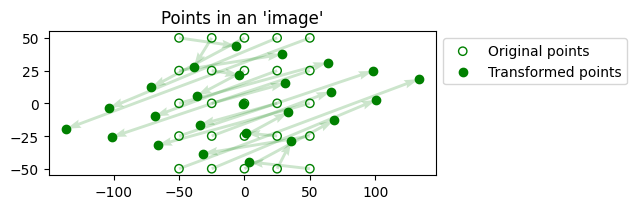

In [8]:
pts = point_grid((-50, 50), (-50, 50), N=5)
A_true, t_true = random_affine_transformation()
pts_prime = apply_affine_transformation(pts, A_true, t_true)


# Visualize the original and transformed points
f, ax = plot_affine_test_case(pts, pts_prime)

### Task 1.4
Make a minimal solver for the case of affine transformation estimation. In other words, make a function `estimate_affine` that estimates an affine transformation mapping `pts` to `pts_prime`, where `pts` and `pts_prime` are `2xK` - arrays and $K$ is at least the number you found in the previous exercise. Try your function on your previously generated set of points.

Hint: Use `np.linalg.lstsq` to solve the system of equations.


In [9]:
def estimate_affine(pts: np.ndarray, pts_prime: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate the affine transformation matrix A and translation vector t
    that maps pts to pts_prime.
    
    Args:
    - pts (np.ndarray): Original points, shape (2, N)
    - pts_prime (np.ndarray): Transformed points, shape (2, N)
    
    Returns:
    - A (np.ndarray): Affine transformation matrix, shape (2, 2)
    - t (np.ndarray): Translation vector, shape (2, 1)
    """
    # YOUR CODE HERE
    N = pts.shape[1]

    ones = np.ones((1, N))
    p_hom = np.vstack((pts, ones))
    
    M = p_hom.T
    B = pts_prime.T
    X, residuals, rank, s = np.linalg.lstsq(M, B, rcond=None)

    T = X.T
    A_est = T[:, :2]
    t_est = T[:, 2:] 
    
    return A_est, t_est

In [10]:
# Use the points from the previous cell to test the estimation
A_est, t_est = estimate_affine(pts, pts_prime)


In [81]:
compare_estimated_transform(A_true, t_true, A_est, t_est)

,a,b,c,d,tx,ty
True,0.662057,-1.255651,0.325218,1.834297,-2.087332,0.994003
Estimated,0.662057,-1.255651,0.325218,1.834297,-2.087332,0.994003


### Task 1.5
Create a function `apply_affine_transformation_outlier` that takes the original `pts` and original transform `A, t` and selects a few points that transform differently, so-called outliers. Choose the outliers at a rate `outlier_rate`.

In [ ]:
def apply_affine_transformation_outlier(pts: np.ndarray, A: np.ndarray, t: np.ndarray, outlier_rate: float = 0.2) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply an affine transformation to a set of points and add outliers.

    Args:
    - pts (np.ndarray): Original points, shape (2, N)
    - A (np.ndarray): Affine transformation matrix, shape (2, 2)
    - t (np.ndarray): Translation vector, shape (2, 1)
    - outlier_rate (float): The rate of outliers to be added.

    Returns:
    - pts_prime (np.ndarray): Transformed points with outliers, shape (2, N)
    - outlier_idxs (np.ndarray): Boolean array indicating outliers, shape (N,)
    """
    # YOUR CODE HERE
    N = pts.shape[1]

    pts_prime = (A @ pts) + t

    random_probs = np.random.rand(N)
    outlier_idxs = random_probs < outlier_rate
    num_outliers = np.sum(outlier_idxs)

    random_coords = np.random.uniform(-100, 100, size=(2, num_outliers))
    pts_prime[:, outlier_idxs] = random_coords

    return pts_prime, outlier_idxs

In [23]:
outlier_rate = 0.1
n_samples = 10

# Generate the ground truth data with outliers
pts = point_grid((-50, 50), (-50, 50), N=n_samples)
A_true, t_true = random_affine_transformation()
pts_prime, outlier_idxs = apply_affine_transformation_outlier(pts, A_true, t_true, outlier_rate)

We can visualize the difference between outliers and inliers. In the following plot, the green box marks the original "image", and the green rings the original, non-transformed points.

Inlier points (generated with $A\boldsymbol{x}+t$, green) will transform similarly. Outlier points (generated randomly, red) will not transform similarly to the inlier points. Ideally, we wish to estimate the transformation based on the inlier points only.

Try varying the outlier ratio to better understand the difference between points.

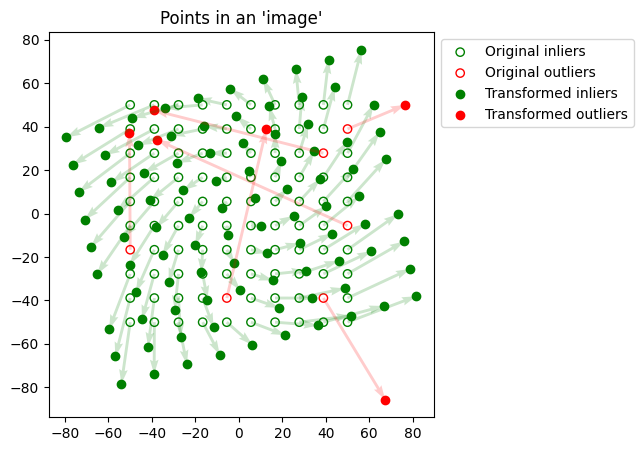

In [24]:
f, ax = plot_affine_test_case_outlier(pts, pts_prime, outlier_idxs)
plt.show()

We try to estimate the transformation given that there are outliers, and estimate the new coordinates for all points.

In [25]:
# Estimate the affine transformation using least squares
A_est, t_est = estimate_affine(pts, pts_prime)

# Apply the estimated transformation to the original points
pts_est = apply_affine_transformation(pts, A_est, t_est)

compare_estimated_transform(A_true, t_true, A_est, t_est)

,a,b,c,d,tx,ty
True,1.357025,-0.252785,0.403091,1.134157,1.158394,-1.517930
Estimated,1.274464,-0.270587,0.343924,1.104112,-0.362357,-0.326019


The transform we estimated on the data with outliers may be also be visualized. In this plot, the green and yellow crosses show the estimated transforms on the inliers and outliers respectively. What are your observations?

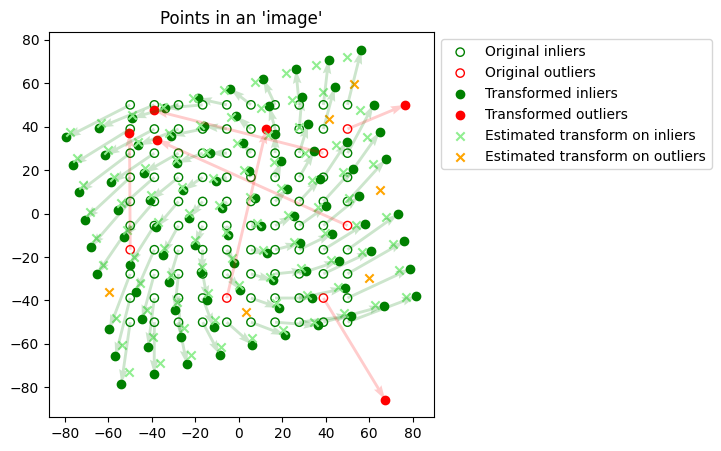

In [27]:
f, ax = plot_affine_test_case_outlier_with_est(pts, pts_prime, pts_est, outlier_idxs)


**Your answer:**


The estimated transforms fails to align with the true transformed inliers, so the estimated grid is severely skewed and rotated away from the ground truth.

Because the standard least squares solver minimizes the sum of squard errors, a few random outliers with massive errors will influence the model serverely. The algorithm runis the alignment of the majority of good points just to reduce the massive penalties caused by the outliers. 

### Task 1.6

We will now see if we can discount the effect of outliers, using the RANSAC algorithm. First, make a function `residual_sum_of_squares`, computing the sum of the squared residuals between the transformed points and the given points. The function should return an array with *N* values. 

In [ ]:
def residual_sum_of_squares(A: np.ndarray, t: np.ndarray, pts: np.ndarray, pts_prime: np.ndarray) -> np.ndarray:
    """
    Calculate the residual sum of squares between the transformed points and the given points.
    
    Args:
    - A (np.ndarray): Affine transformation matrix, shape (2, 2)
    - t (np.ndarray): Translation vector, shape (2,)
    - pts (np.ndarray): Original points, shape (2, N)
    - pts_prime (np.ndarray): Transformed points, shape (2, N)

    Returns:
    - residual_ss (np.ndarray): Residual sum of squares, shape (N,)
    """
    # YOUR CODE HERE
    pts_estimated = (A @ pts) + t

    diff = pts_estimated - pts_prime
    squared_diff = diff ** 2

    return np.sum(squared_diff, axis=0)


### Task 1.7
A naïve estimation of the transformation from `pts` to `pts_prime` (e.g. the least-squares solution) would be influenced by the outlier points. RANSAC is a method used to reject outliers and recover the underlying affine transformation from the inlier correspondences.

Make a function `ransace_fit_affine` that uses RANSAC to find an affine transformation between two sets of points (like before the transformation should map `pts` onto `pts_prime`). Use the function `residual_sum_of_squares` to find the in- vs. outliers. 


In [29]:

def ransac_fit_affine(pts: np.ndarray, pts_prime: np.ndarray, thresh: float, n_iter: int = 10000, max_inliers: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estimate the affine transformation matrix A and translation vector t
    using RANSAC to handle outliers.
    
    Args:
    - pts (np.ndarray): Original points, shape (2, n)
    - pts_prime (np.ndarray): Transformed points, shape (2, n)
    - thresh (float): Threshold for considering a point as an inlier
    - n_iter (int): Number of iterations for RANSAC
    - max_inliers (int): Maximum number of inliers found

    Returns:
    - A (np.ndarray): Affine transformation matrix, shape (2, 2)
    - t (np.ndarray): Translation vector, shape (2, 1)
    """
    # YOUR CODE HERE
    N = pts.shape[1]

    best_A = None
    best_t = None
    best_inlier_count = -1
    min_samples = 3

    for i in range(n_iter):
        sample_idxs = np.random.choice(N, min_samples, replace=False)
        pts_sample = pts[:, sample_idxs]
        pts_prime_sample = pts_prime[:, sample_idxs]

        A_hypothesis, t_hypothesis = estimate_affine(pts_sample, pts_prime_sample)
        residuals = residual_sum_of_squares(A_hypothesis, t_hypothesis, pts, pts_prime)

        inlier_indxs = residuals < thresh
        inlier_count = np.sum(inlier_indxs)

        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_A = A_hypothesis
            best_t = t_hypothesis

            if max_inliers > 0 and best_inlier_count >= max_inliers:
                break
    
    return best_A, best_t





In [32]:
n_samples = 10
thresh = 0.5
outlier_rate = 0.1

# Generate the ground truth data with outliers
pts = point_grid((-50, 50), (-50, 50), N=n_samples)
A_true, t_true = random_affine_transformation()
pts_prime, outlier_idxs = apply_affine_transformation_outlier(pts, A_true, t_true, outlier_rate)

# Estimate the affine transformation using RANSAC
A_est, t_est = ransac_fit_affine(pts, pts_prime, thresh=thresh)

# Apply the estimated transformation to the original points
pts_est = apply_affine_transformation(pts, A_est, t_est)

In [33]:
compare_estimated_transform(A_true, t_true, A_est, t_est)

,a,b,c,d,tx,ty
True,-0.440195,-0.023513,-1.44781,-0.234536,2.263662,-1.292816
Estimated,-0.440195,-0.023513,-1.44781,-0.234536,2.263662,-1.292816


Explain your observations with different values of threshold. Why do arbitrarily small values of threshold work in this case?

**Your Answer:**

When thresh is small, RANSAC correctly classifies inliers. while when thres is too large, RANSAC incorrectly classifies random outliers as inliers, and causes the final estimated affine transformation to degrade. 

The reason is that the data we generated is pefect and noise-free. So the true residual for an inlier in this simulation is 0, even arbitrarily small values of threshold can identify them correctly.

We visualize the estimated transformation. Inlier points (green) should be estimated correctly (green crosses), while the impact of the outlier points (red) should be disregarded.

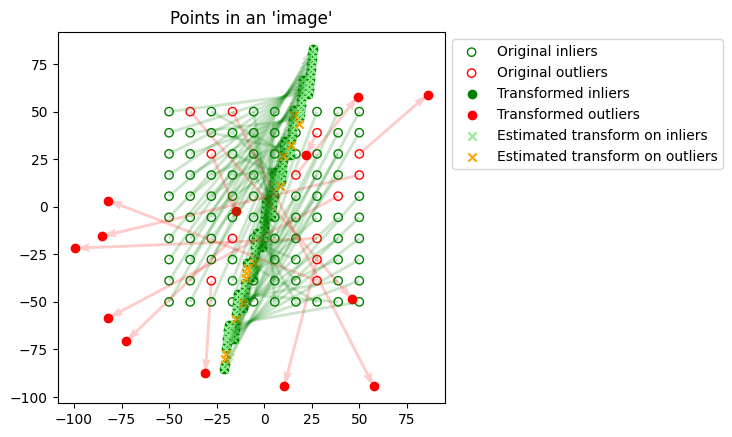

In [35]:
f, ax = plot_affine_test_case_outlier_with_est(pts, pts_prime, pts_est, outlier_idxs)


**Observe**: 
In real world applications, we do not have the actual ground truth transform. Rather, we start with a target image, for example containing features points, and a second image, referred to as the source image, with corresponding feature points. The objective is then to find a transformation that maps feature point coordinates.

### Task 2.1 Real world registration
For this exercise, we will estimate the transformation matrix between two images. We will use SIFT to extract features from images in a source image at `source_path`, and a target image at `target_path`. However, to estimate the matrix (e.g. using RANSAC), we need point *correspondences*, that is *matched* points between the source and target. 

As such, we will use the supplied functions `extract_sift_features` and `match_descriptors` to find good points and match them between the images. Use these points to estimate the transformation using your `ransac_fit_affine` function.

The image will then be warped using the supplied `affine_warp` function, which takes the source image, the affine transformation matrix (note: from source to target, e.g. forward warping convention), and the target image size as input.

Make a function `align_images(source, target, thresh, plot)` where `thresh` is the threshold for the outliers in the `ransac_fit_affine` function, and `plot` is a boolean argument to plot the correspondences. You can use the function `plot_matches` in `visualization.py` for this (not compulsory).

We will work in grayscale for simplicity, but observe that the functions use the OpenCV library for SIFT and RANSAC, and require images to be in `uint8` (0-255) format. 

In [36]:
def extract_sift_features(image: np.ndarray) -> Tuple[Sequence[cv2.KeyPoint], cv2.UMat]:
    """
    Extracts SIFT descriptors from an image.

    Args:
    - image (np.ndarray): The input image.

    Returns:
    - Tuple[Sequence[cv2.KeyPoint], cv2.UMat]: A tuple containing the keypoints and descriptors.
    """
    
    # Create a SIFT detector
    sift = cv2.SIFT.create()

    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(image, None)
    
    return keypoints, descriptors

def match_descriptors(
        descriptors_src: cv2.UMat, 
        descriptors_tgt: cv2.UMat, 
        max_ratio: float = 0.8) -> Tuple[Sequence[Sequence[cv2.DMatch]], Sequence[Sequence[cv2.DMatch]]]:
    """
    Matches descriptors from the test image to the training descriptors using brute-force
    matches and Lowe's ratio test.

    Returns the good matches and all matches.

    Args:
    - descriptors_src (cv2.UMat): The source image descriptors.
    - descriptors_tgt (cv2.UMat): The target image descriptors.
    - max_ratio (float): The maximum ratio for Lowe's ratio test.

    Returns:
    - Tuple[Sequence[Sequence[cv2.DMatch]], Sequence[Sequence[cv2.DMatch]]]: A tuple containing the good matches and all matches.

    """
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(descriptors_src, descriptors_tgt, k=2)

    # Apply Lowe's ratio test
    good_matches = []

    # Iterate through the matches and apply the ratio test
    # selecting only the good matches
    for i, (m,n) in enumerate(matches):
        if m.distance < max_ratio * n.distance:
            good_matches.append([m])

    return good_matches, matches



def extract_keypoint_matches(
        pts_src: Sequence[cv2.KeyPoint], 
        pts_tgt: Sequence[cv2.KeyPoint], 
        matches: Sequence[Sequence[cv2.DMatch]]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extracts the matched keypoints from the source and target images.

    Args:
    - pts_src (Sequence[cv2.KeyPoint]): The keypoints from the source image.
    - pts_tgt (Sequence[cv2.KeyPoint]): The keypoints from the target image.
    - matches (Sequence[Sequence[cv2.DMatch]]): The matches between the keypoints.

    Returns:
    - Tuple[numpy.ndarray, numpy.ndarray]: A tuple containing the matched keypoints from the source and target images.
    """
    
    pts_src_to_use = [pts_src[m[0].queryIdx].pt for m in matches]
    pts_tgt_to_use = [pts_tgt[m[0].trainIdx].pt for m in matches]
    pts_src_to_use = np.array(pts_src_to_use).astype(np.float32).T
    pts_tgt_to_use = np.array(pts_tgt_to_use).astype(np.float32).T

    return pts_src_to_use, pts_tgt_to_use


def plot_matches(
        source: np.ndarray,
        target: np.ndarray, 
        pts_src: Sequence[cv2.KeyPoint], 
        pts_tgt: Sequence[cv2.KeyPoint], 
        matches: Sequence[Sequence[cv2.DMatch]], 
        max_ratio: float = 0.8,
        ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plots the matches between two images.
    
    Args:
    - source np.ndarray: The source image.
    - target np.ndarray: The target image.
    - pts_src (Sequence[cv2.KeyPoint]): Keypoints from the source image.
    - pts_tgt (Sequence[cv2.KeyPoint]): Keypoints from the target image.
    - matches (Sequence[Sequence[cv2.DMatch]]): All matches between the keypoints.
    - max_ratio (float): The maximum ratio for Lowe's ratio test.

    Returns:
    - Tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    
    """

    match_mask = [[0, 0] for i in range(len(matches))]
    for i, (m,n) in enumerate(matches):
        if m.distance < max_ratio * n.distance:
            match_mask[i] = [1, 0]
    
    plot_kwargs = {
        'matchColor': (0, 255, 0, 0.2),
        'singlePointColor': (255, 0, 0),
        'matchesMask': match_mask,
        'flags': cv2.DrawMatchesFlags_DEFAULT
    }
    img_to_plot = cv2.drawMatchesKnn(source, pts_src, target, pts_tgt, matches, None, **plot_kwargs)

    f, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_to_plot)
    ax.axis('off')
    ax.set_title('Matches')

    return f, ax



In [49]:
def read_as_grayscale(image_path: str) -> np.ndarray:
    """
    Reads an image from the specified path and converts it to grayscale.

    Args:
    - image_path (str): The path to the image file.

    Returns:
    - np.ndarray: The grayscale image as a NumPy array.
    """
    # YOUR CODE HERE
    return cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


def align_images(
        source: np.ndarray, 
        target: np.ndarray, 
        thresh: float = 10, 
        plot: bool=False) -> Tuple[np.ndarray, np.ndarray]:
    """Aligns the source image to the target image using SIFT features and RANSAC for affine transformation estimation.

    Args:
    - source (np.ndarray): The source image to be aligned.
    - target (np.ndarray): The target image to align to.
    - thresh (float): The threshold for RANSAC inlier determination.
    - plot (bool): Whether to plot the matches between the images.

    Returns:
    - np.ndarray: The aligned (warped) source image.
    - np.ndarray: The estimated transformation matrix.
    """
    # YOUR CODE HERE
    kps_src, descs_src = extract_sift_features(source)
    kps_tgt, descs_tgt = extract_sift_features(target)
    good_matchs, all_matches = match_descriptors(descs_src, descs_tgt)

    if plot:
        plot_matches(source, target, kps_src, kps_tgt, all_matches)
        plt.show()

    pts_src, pts_tgt = extract_keypoint_matches(kps_src, kps_tgt, good_matchs)

    A_est, t_est = ransac_fit_affine(pts_src, pts_tgt, thresh=thresh)

    T = np.zeros((3, 3))
    T[:2, :2] = A_est
    T[:2, 2:3] = t_est.reshape(2, 1)
    T[2, 2] = 1.0

    aligned_source =affine_warp(source, T, target.shape)
    return aligned_source, T




### Task 2.2
Align `vermeer_source.png` to `vermeer_target.png`. 

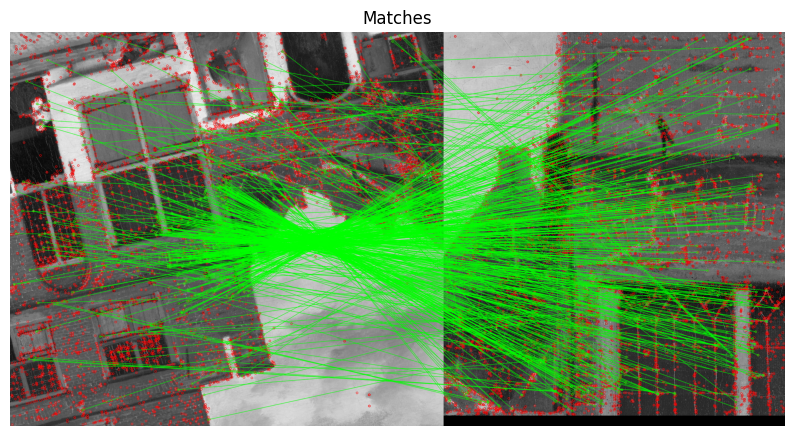

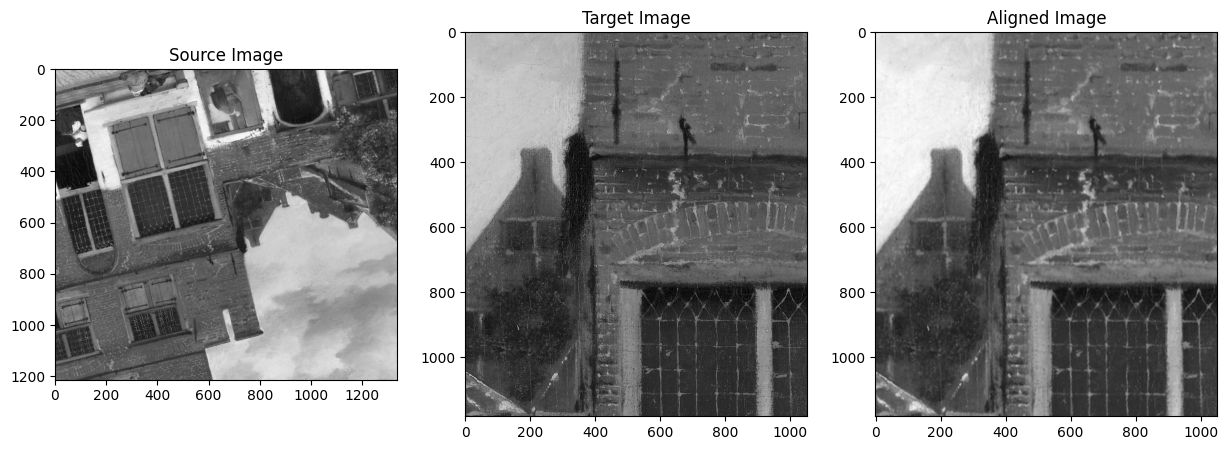

In [50]:

source = read_as_grayscale('./data/vermeer_source.png')
target = read_as_grayscale('./data/vermeer_target.png')

warped, T  = align_images(source, target, thresh=0.1, plot=True)

f, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(source, cmap='gray')
ax[0].set_title('Source Image')
ax[1].imshow(target, cmap='gray')
ax[1].set_title('Target Image')
ax[2].imshow(warped, cmap='gray')
ax[2].set_title('Aligned Image')

plt.show()



### Task 2.3
Try aligning the images `CT_1.jpg` and `CT_2.jpg`. Although SIFT is designed to be robust to changes in illumination and contrast, in practice, strong differences in intensity distributions can still affect keypoint detection and matching quality. 

Therefore, write a preprocessing function to make the points more distinguishable and features more similar. Consider things like colours, contrast and histogram equalization.

In [45]:
def preprocess_ct_image(image: np.ndarray) -> np.ndarray:
    """
    Preprocesses a CT image.

    Args:
    - image (np.ndarray): The input CT image.

    Returns:
    - np.ndarray: The preprocessed CT image.
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [46]:
target = read_as_grayscale('./data/CT_1.jpg')
source = read_as_grayscale('./data/CT_2.jpg')

source = preprocess_ct_image(source)
target = preprocess_ct_image(target)

# Align the images using the function you implemented
warped, T  = align_images(source, target, thresh=200, plot=True)

f, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(source, cmap='gray')
ax[0].set_title("Source image")
ax[1].imshow(target, cmap='gray')
ax[1].set_title("Target image")
ax[2].imshow(warped, cmap='gray')
ax[2].set_title("Warped image")

ax[3].imshow(target, cmap='gray')
ax[3].imshow(warped, cmap='Reds', alpha=0.5)
ax[3].set_title("Overlay of warped and target")
ax[3].axis('off')

plt.show()

NotImplementedError: 

Try varying the threshold for the inliers. What values are required to properly register the image? What are possible reasons for this?

**Your Answer**: 

### Task 2.4
Try aligning `tissue_fluorescent.tif` and `tissue_brightfield.tif`. 

Sometimes, some pre-processing is actually required. In the fluorescent image, the intensities are basically inverted, so you need to invert one of the images before computing descriptors. (Otherwise you will not get any good matches.) 

You may also find it helpful to do some pre-preprocessing of the image intensities.

In [ ]:
def preprocess_source_image(image: np.ndarray) -> np.ndarray:
    """
    Preprocesses a fluorescence microscopy image.

    Args:
    - image (np.ndarray): The input fluorescence microscopy image.

    Returns:
    - np.ndarray: The preprocessed fluorescence microscopy image.
    """
    # YOUR CODE HERE
    raise NotImplementedError()

def preprocess_target_image(image: np.ndarray) -> np.ndarray:
    """
    Preprocesses a fluorescence microscopy image.

    Args:
    - image (np.ndarray): The input fluorescence microscopy image.

    Returns:
    - np.ndarray: The preprocessed fluorescence microscopy image.
    """
    # YOUR CODE HERE
    raise NotImplementedError()


In [ ]:
source = read_as_grayscale('./data/tissue_brightfield.tif')
target = read_as_grayscale('./data/tissue_fluorescent.tif')

source = preprocess_source_image(source)
target = preprocess_target_image(target)

warped, T = align_images(source, target, thresh=100, plot=True)

f, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(source, cmap='gray')
ax[0].set_title("Source image")
ax[1].imshow(target, cmap='gray')
ax[1].set_title("Target image")
ax[2].imshow(warped, cmap='gray')
ax[2].set_title("Warped image")

ax[3].imshow(target, cmap='gray')
ax[3].imshow(warped, cmap='Reds', alpha=0.2)
ax[3].set_title("Overlay of warped and target")
ax[3].axis('off')

plt.show()

### Task 3.1 Non-rigid (deformable) registration
Simple rotation, translation and even scaling is generally not enough to describe the level of variability that may occur between a source and target image, in particular in for example medical images, where motifs may have deformed between the moments of acquisition. In cases like these, e.g. the skeleton CT slice above, the strategies we have learnt so far will never be sufficient. As such, it is common to use non-rigid, deformable registration, enabling pixels and regions to deform locally.

You are given a template function called `deformable_register_2d` that uses `SimpleITK` for deformable registration. Deformable registration has two particularly important parameters, the choice of _metric_ that evaluates the registration between source and target, and _shrink factors_, that determine a pyramidal series of scales, that does registration incrementally from coarse to fine.

Update the given function to select a metric from the arguments. It should be possible to choose (at least) MSE, correlation and mutual information.

In [ ]:
def deformable_register_2d(fixed: np.ndarray, moving: np.ndarray, metric: str = 'correlation', shrink_factors=[8, 4, 2, 1]) -> Tuple[np.ndarray, sitk.Transform]:
    """Performs deformable registration of two 2D images using SimpleITK.

    Args:
    - fixed (np.ndarray): The fixed image to which the moving image will be registered.
    - moving (np.ndarray): The moving image that will be registered to the fixed image.
    - metric (str): The similarity metric to use for registration. Options are 'correlation', 'mutual_information', and 'mean_squares'.
    - shrink_factors (list): The shrink factors for the multi-resolution registration.
    Returns:
    - np.ndarray: The registered (warped) moving image.
    - sitk.Transform: The final transformation that maps the moving image to the fixed image.
    """

    fixed = sitk.GetImageFromArray(fixed)
    moving = sitk.GetImageFromArray(moving)
    fixed.SetSpacing((1.0, 1.0))
    moving.SetSpacing((1.0, 1.0))

    # The ImageRegistrationMethod class in SimpleITK provides a framework for performing image registration,
    # where each component of the registration process (metric, transformation model, interpolator, optimizer, etc.)
    # is set using a method of the registration object.
    reg = sitk.ImageRegistrationMethod()

    # The metric determines how the similarity 
    # between the fixed and moving images is measured during registration.
    # YOUR CODE HERE
    # API: reg.setMetric...
    raise NotImplementedError()

    # The transformation model defines the type of transformation that will be estimated during registration.
    # A B-spline transformation is a flexible model that can capture complex deformations, 
    # making it suitable for deformable registration.
    # The mesh size determines the number of control points in the B-spline transformation,
    # which in turn affects the flexibility of the transformation.
    mesh_size = [2, 2]
    transform = sitk.BSplineTransformInitializer(
        fixed, mesh_size
    )
    reg.SetInitialTransform(transform, inPlace=False)

    # The interpolator determines how the moving image is resampled during registration.
    reg.SetInterpolator(sitk.sitkLinear)

    # The optimizer determines how the registration algorithm 
    # searches for the optimal transformation parameters.
    reg.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-7,
        numberOfIterations=10,
        maximumNumberOfCorrections=5,
        maximumNumberOfFunctionEvaluations=100,
        costFunctionConvergenceFactor=1e7
    )

    # A multi-resolution framework allows the registration to be performed at multiple scales,
    # which can help to improve convergence and avoid local minima.
    reg.SetShrinkFactorsPerLevel(shrink_factors)
    reg.SetSmoothingSigmasPerLevel([1] * len(shrink_factors)) 

    final_transform = reg.Execute(fixed, moving)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    resampler.SetTransform(final_transform)

    result = resampler.Execute(moving)

    result = sitk.GetArrayFromImage(result)

    return result, final_transform

### Task 3.2
Try to use deformable registration using correlation and scaling shrink factors of `[8, 4, 2, 1]` on the skeleton data. How does it perform? Try to implement what may be an important pre-requisite without modifying your registration function. What was your solution?

In [ ]:
target = read_as_grayscale('./data/CT_1.jpg')
source = read_as_grayscale('./data/CT_2.jpg')

source = preprocess_ct_image(source)
target = preprocess_ct_image(target)

# Preprocess the images for deformable registration
# SITK requires the images to be in float format and normalized to the range [0, 1]
source_float = source.astype(np.float32)
target_float = target.astype(np.float32)
source_float /= 255
target_float /= 255

warped, T  = align_images(source, target, thresh=200, plot=False)

# YOUR CODE HERE
# ...


# Plot target image in the warped image, using the same coordinates
f, ax = plt.subplots(1, 2, figsize=(10, 15))
ax[0].imshow(target_float, cmap='gray')
ax[0].imshow(warped, cmap='Reds', alpha=0.5)
ax[0].set_title("Target image warped to source image")
ax[0].axis('off')

ax[1].imshow(target_float, cmap='gray')
ax[1].imshow(non_rigid_warped, cmap='Reds', alpha=0.5)
ax[1].set_title("Target image non-rigidly warped to source image")
ax[1].axis('off')



plt.show()

**Your Answer:**


### Task 3.3
Investigate the impact of the shrink factors and different registration metrics, and visualize the results. 

What are your conclusions? 
Which parameter seems the most important?
Do you observe anything weird, if so, what may be the cause?

In [ ]:
# YOUR CODE HERE

**Your Answer**:


### Task 4.1 Warping
So far, you have used the OpenCV functions for warping the images, and we have not had to consider the mechanisms of actually reconstructing the image and its pixels given the transformation matrix.

The algorithm for backwards warping to the original image can intuitively be written 

```
for each pixel (x,y) in the transformed image:
    1. Compute the transformed pixel coordinates (x', y')
    2. Resample the source image intensities at (x', y')
```

It is fairly difficult to write a fast implementation for warping, so you will make a naïve version for small images.

You will first create a simple sampling function (step 2 in the algorithm) using neareast neighbours. Make a function `sample_image_at(image, position)` that gives you the pixel value at position. If the elements of position are not integers, select the value at the closest pixel. If it is outside the image, return 255 (i.e. white). Try the function on the transformed image `source_16x16.tif` to make sure it works.

In [ ]:
def sample_image_at(image: np.ndarray, position: Tuple[float, float]) -> np.ndarray:
    """
    Sample a square region from the image at the given position.
    
    Args:
    - image (np.ndarray): The input image (uint8).
    - position (Tuple[float, float]): The center position of the square region.
    
    Returns:
    - sampled_image (np.ndarray): The sampled square region.
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
image = read_as_grayscale('./data/source_16x16.tif')
coords = (4, 5)
value = sample_image_at(image, coords)
print(value)

f, ax = plt.subplots(1, 1)
ax.imshow(image, cmap='gray')
ax.scatter(coords[0], coords[1], color='red', marker='x')
ax.text(coords[0]+0.5, coords[1]+0.5, f'{value}', color='red')
plt.show()

### Task 4.2
Now, you will make a warping function that warps a 16 x 16 image according to the coordinate transfomation provided in the supplied function `transform_coordinates`

Make a function `warp_16x16(source)` that warps source according to the function `transform_coordinates` and forms an output 16 x 16 image warped. 

`transform_coordinates` defines the transformation from target to source coordinates, that is, it takes a 2-vector `target_pos` as input, and maps it to the source image. 

In your function, loop over all target pixels and use the transformation along with your function `sample_image_at` to extract pixel values from the source image. Try the function on `source_16x16.tif`. You will know if you get it right. Also make sure that the orientation is correct!

In [ ]:
def transform_coordinates(pos: List[float]) -> List[float]:
    """"
    Transform the coordinates of a point from the target image to the source image."
    
    Args:
    - pos (list): The coordinates of the point in the target image.

    Returns:
    - list: The coordinates of the point in the source image.
    """

    dx, dy = get_delta(pos[0], pos[1])
    pos_prime = [pos[0] + dx, pos[1] + dy]
    return pos_prime

def get_delta(x: int, y: int) -> Tuple[int, int]:
    """
    Get the transformation of a point from the target image to the source image.

    Args:
    - x (int): The x-coordinate of the point in the target image.
    - y (int): The y-coordinate of the point in the target image.

    Returns:
    - Tuple[int, int]: The transformed coordinates.
    """

    x = min(max(x, 0), 15)
    y = min(max(y, 0), 15)

    rowd = np.array([
        [0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0],
        [-2, 0,  0,  0,  0,  1,  1,  1,  1, -1, -1, 0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0.2],
        [0,  0,  0,  0,  0,  2,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0,  0, -1, 0],
        [0,  0, -2, -2, 0,  -1, -1, -1, -1, -1, -1, -1, -2, -2, -2, 0],
        [0,  0,  0,  0,  0,  0, -2, 0,  0, -2, 0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  2,  0,  0,  2,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, 0,  0,  0,  0],
        [0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, 0,  0,  0,  0]
    ])

    cold = np.array([
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0, -1, 0,  0,  0,  0,  0,  0,  0],
        [0,  0,  1, -1, -2, 0,  0,  0, -1, 0,  0,  0, -1, -1, 0,  0],
        [0,  2,  0, -1, 0,  0,  0,  0, -1, -2, 0,  0, -1, 0,  -2, 0],
        [0,  2,  0,  1,  0, -3, 2,  1,  0, -2, -3, 0, -1, 0,  -2, 0],
        [3,  3,  2,  1, -2, -3, 2,  1,  0,  0, -3, -4, -5, -6, -7, -3],
        [3,  3,  2,  1, -2, -3, 2,  1,  0,  0, -3, -4, -1, 0,  -7, -3.1],
        [3,  0,  2,  1, -2, -3, 2,  1,  0,  0, -3, 0,  -1, 0,  0,  -3],
        [3,  0,  0,  1,  0,  0,  0,  1,  0, -2, -3, 0,  -1, 0,  0,  -3],
        [3,  0,  0,  1,  0,  0,  0,  0, -1, -2, -3, -4, 1,  0,  -7, -3],
        [3,  0,  2,  1, -1, 0,  0,  0,  0,  0,  0,  0, -5, -6, -7, -3],
        [0,  2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  -1, -2, 0],
        [0,  0,  1, -1, 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, 0,  0],
        [0,  0,  1, -1, 0,  0,  0,  0,  0,  0,  0,  0, -1, -1, 0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]
    ])

    dy = rowd[y, x]
    dx = cold[y, x]
    return dx, dy

In [ ]:
def warp_16x16(source: np.ndarray) -> np.ndarray:
    """
    Warp a 16x16 square region from the source image.
    
    Args:
    - source (numpy.ndarray): The input image (uint8).
    
    Returns:
    - warped_image (numpy.ndarray): The warped 16x16 square region.
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
image = read_as_grayscale('./data/source_16x16.tif')
warped = warp_16x16(image)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(warped, cmap='gray')
ax[1].set_title('Warped Image')
plt.show()